In [40]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_json('cleaned_meta_beauty.json', lines=True)
#df = pd.read_parquet('master_product_vectors_TFIDF.parquet')

In [41]:
df.head(5)

,average_rating,categories,main_category,parent_asin,rating_number,store,description,title,features_string,Age Range (Description),Brand,Item Form,Material,Hair Type
0,4.8,[],All Beauty,B01CUPMQZE,10,Howard Products,,howard lc008 leather conditioner 8 ounce 4 pack,,NaN,NaN,NaN,NaN,NaN
1,4.5,[],All Beauty,B076WQZGPM,3,Yes To,,yes tomato detoxifying charcoal cleanser pack ...,,Adult,Yes To,Powder,NaN,NaN
2,4.4,[],All Beauty,B000B658RI,26,Levine Health Products,,eye patch black adult tie band 6 per pack,,NaN,NaN,NaN,NaN,NaN
3,3.1,[],All Beauty,B088FKY3VD,102,Cherioll,,tattoo eyebrow sticker waterproof eyebrow 4d i...,,NaN,Cherioll,Powder,NaN,NaN
4,4.3,[],All Beauty,B07NGFDN6G,7,Precision,precision plunger bar designed work seamlessly...,precision plunger bar cartridge grip 93mm bag ...,material 304 stainless steel brass tip length ...,NaN,NaN,NaN,NaN,NaN


Original size: 112590
Sampled size: 22518


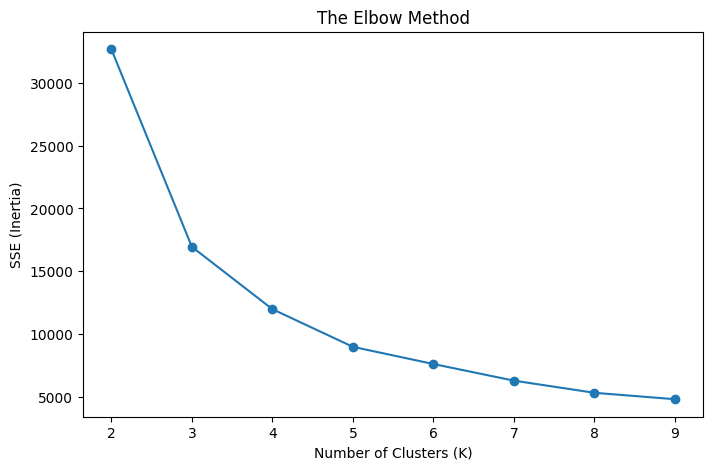

For k=2, Silhouette Score is 0.2840
For k=3, Silhouette Score is 0.4130
For k=4, Silhouette Score is 0.4023
For k=5, Silhouette Score is 0.4055
For k=6, Silhouette Score is 0.3852
For k=7, Silhouette Score is 0.3865
For k=8, Silhouette Score is 0.3927
For k=9, Silhouette Score is 0.3754
For k=10, Silhouette Score is 0.3785


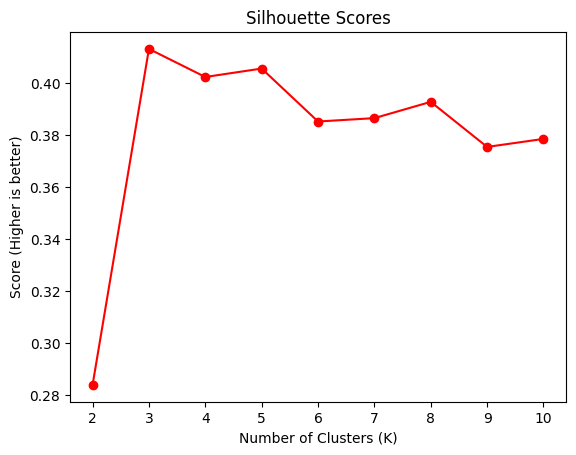

0

In [42]:
from sklearn.metrics import silhouette_score

# BFR clustering with numerical data

# run standard k-mean with 20% of data to find initial centroid
df_sampled = df.sample(frac=0.2, random_state=42)
df_sampled['log_votes'] = np.log1p(df_sampled['rating_number'])
features = df_sampled[['average_rating','log_votes']]
# verify data size
print(f"Original size: {len(df)}")
print(f"Sampled size: {len(df_sampled)}")

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
sse = [] 
k_range = range(2, 10)

def find_k(scaled_features):
    sse = [] 
    k_range = range(2, 10)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        kmeans.fit(scaled_features)
        sse.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, sse, marker='o')
    plt.title('The Elbow Method')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('SSE (Inertia)')
    plt.show()
    return 0


def silhouette_score_fn(scaled_features):
    scores = []
    k_range = range(2, 11)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        labels = kmeans.fit_predict(scaled_features)
        score = silhouette_score(scaled_features, labels)
        scores.append(score)
        print(f"For k={k}, Silhouette Score is {score:.4f}")

    # Plotting the scores
    plt.plot(k_range, scores, marker='o', color='red')
    plt.title('Silhouette Scores')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Score (Higher is better)')
    plt.show()
    return 0
    
 
    
find_k(scaled_features)
silhouette_score_fn(scaled_features)

In [43]:
import numpy as np
# we select k = 3 because it has the highest silhouette score
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(scaled_features)

initial_centroids = kmeans.cluster_centers_ 
labels = kmeans.labels_ 

# add label to data frame to calculate stat data in each cluster
df_sampled['cluster_id'] = labels
df_features = df_sampled[['average_rating','log_votes','cluster_id']]

# initial centroids
bfr_ds_stats = {}

for cluster_id in range(len(initial_centroids)):
    cluster_data = df_features[df_features['cluster_id'] == cluster_id].drop(columns=['cluster_id'])
    # calculate BFR required stats
    n = len(cluster_data)
    sum_vals = cluster_data.sum(axis=0).values
    print(f"sumvalue: {sum_vals}")
    sumsq_vals = (cluster_data**2).sum(axis=0).values
    
    # store stat data for each cluster
    bfr_ds_stats[cluster_id] = {
        'N': n,
        'SUM': sum_vals,
        'SUMSQ': sumsq_vals,
        'Centroid': initial_centroids[cluster_id]
    }

print(f"Stored stats for {len(bfr_ds_stats)} clusters.")
print(f"num of cluster 0 : {bfr_ds_stats[0]['N']}")
print(f"num of cluster 1 : {bfr_ds_stats[1]['N']}")
print(f"num of cluster 2 : {bfr_ds_stats[2]['N']}")
# calculate standard deviation for each cluster
for cid in bfr_ds_stats:
    stats = bfr_ds_stats[cid]
    variance = (stats['SUMSQ'] / stats['N']) - (stats['SUM'] / stats['N'])**2
    # ensure no division by zero with a tiny epsilon
    bfr_ds_stats[cid]['std_dev'] = np.sqrt(variance + 1e-9)

sumvalue: [38339.1        14544.07923309]
sumvalue: [16335.         10206.52651573]
sumvalue: [32623.4        32511.15136525]
Stored stats for 3 clusters.
num of cluster 0 : 8548
num of cluster 1 : 5885
num of cluster 2 : 8085


In [44]:

# perform to the 90% remaining data set
df_remaining = df.drop(df_sampled.index)
df_remaining['log_votes'] = np.log1p(df_remaining['rating_number'])
df_remaining = df_remaining[['average_rating','log_votes']]

scaled_features_remain = scaler.transform(df_remaining)

print(f" sample : \n {scaled_features_remain}")
print(f"Total: {len(df)}")
print(f"Sample (10%): {len(df_sampled)}")
print(f"Remaining (90%): {len(df_remaining)}")


# calculate mahalanobis distance
def get_mahalanobis_dist(point, centroid, std_dev):
    normalized_dist = (point - centroid) / std_dev
    return np.sqrt(np.sum(normalized_dist**2))

threshold = 2*np.sqrt(2) 
retanied_set = []


for point in scaled_features_remain:
    
    distances = []
    for cid, stats in bfr_ds_stats.items():
        dist = get_mahalanobis_dist(point, stats['Centroid'], stats['std_dev'])
        distances.append((dist, cid))

    min_dist, best_cid = min(distances)
    
    if min_dist < threshold:
        bfr_ds_stats[best_cid]['N'] += 1
        bfr_ds_stats[best_cid]['SUM'] += point
        bfr_ds_stats[best_cid]['SUMSQ'] += (point**2)
        pass
    else:
        retanied_set.append(point)
   
print(f"the number of outlier : {len(retanied_set)}")      
print(f"the number of data point in cluster 0: {bfr_ds_stats[0]['N']}")
print(f"the number of data point in cluster 1: {bfr_ds_stats[1]['N']}")
print(f"the number of data point in cluster 2: {bfr_ds_stats[2]['N']}")


 sample : 
 [[ 1.05101457 -0.10513111]
 [ 0.70948501 -0.83839542]
 [ 0.59564182  0.54574664]
 ...
 [ 0.48179864 -0.54449187]
 [ 0.14026908 -0.1742172 ]
 [-2.364281   -1.0469233 ]]
Total: 112590
Sample (10%): 22518
Remaining (90%): 90072
the number of outlier : 389
the number of data point in cluster 0: 36942
the number of data point in cluster 1: 33435
the number of data point in cluster 2: 41824


In [45]:
for cid, stats in bfr_ds_stats.items():
    scaled_avg = stats['SUM'] / stats['N']
    log_space_values = scaler.inverse_transform([scaled_avg])
    real_rating = log_space_values[0][0]
    real_votes = np.expm1(log_space_values[0][1])
    
    print(f"Cluster {cid} Corrected:")
    print(f" - Avg Rating: {min(real_rating, 5.0):.2f}")
    print(f" - Avg Votes: {int(real_votes)}")

Cluster 0 Corrected:
 - Avg Rating: 5.00
 - Avg Votes: 9
Cluster 1 Corrected:
 - Avg Rating: 3.50
 - Avg Votes: 9
Cluster 2 Corrected:
 - Avg Rating: 4.71
 - Avg Votes: 104


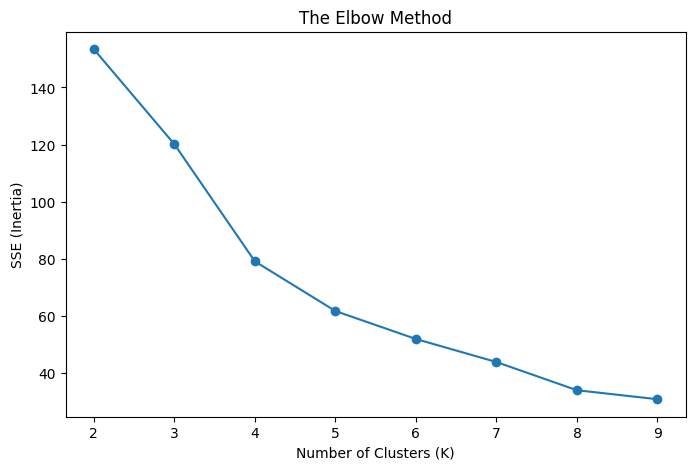

For k=2, Silhouette Score is 0.7336
For k=3, Silhouette Score is 0.5908
For k=4, Silhouette Score is 0.5012
For k=5, Silhouette Score is 0.4480
For k=6, Silhouette Score is 0.4450
For k=7, Silhouette Score is 0.4252
For k=8, Silhouette Score is 0.4367
For k=9, Silhouette Score is 0.4164
For k=10, Silhouette Score is 0.4220


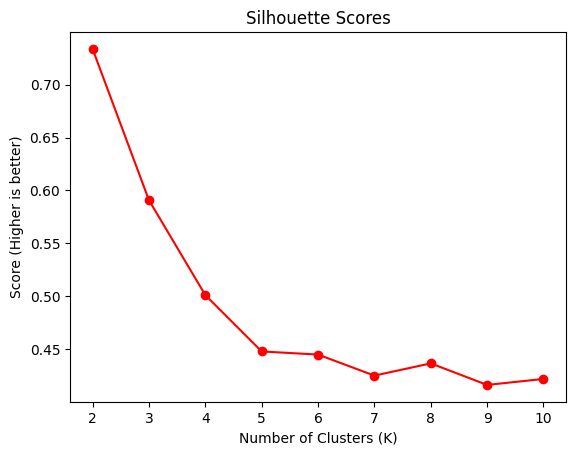

0

In [46]:
# perform clustering on RS to see whether the data belong to CS or RS
from sklearn.cluster import KMeans

# convert list of points to a DataFrame/Array
rs_data = np.array(retanied_set)

# find suitable k value
find_k(rs_data)
silhouette_score_fn(rs_data)

In [47]:
# we select k = 2 because it has the highest silhouette score
kmeans_rs = KMeans(n_clusters=2, init='k-means++', random_state=42)
rs_labels = kmeans_rs.fit_predict(rs_data)
rs_round2 = []
bfr_cs_stats = {}

for mini_cid in range(2):
    mini_cluster_points = rs_data[rs_labels == mini_cid]
    
    if len(mini_cluster_points) > 1:
        bfr_cs_stats[mini_cid] = {
            'N': len(mini_cluster_points),
            'SUM': mini_cluster_points.sum(axis=0),
            'SUMSQ': (mini_cluster_points**2).sum(axis=0),
            'Centroid': mini_cluster_points.mean(axis=0)
        }
    else:
        rs_round2.append(mini_cluster_points)
        pass

for cid in bfr_cs_stats:
    stats = bfr_cs_stats[cid]
    variance = (stats['SUMSQ'] / stats['N']) - (stats['SUM'] / stats['N'])**2
    bfr_cs_stats[cid]['std_dev'] = np.sqrt(variance + 1e-9)  
      
print(f"the num of cluster 1 : {bfr_cs_stats[0]['N']}")
print(f"the num of cluster 2 : {bfr_cs_stats[1]['N']}")
print(f"the num of rs : {len(rs_round2)}")


def merge_sets(ds_stats, cs_stats, threshold):
    to_delete = []
    
    for cs_id, cs_val in cs_stats.items():
        distances = []
        for ds_id, ds_val in ds_stats.items():
            # Calculate distance between CS centroid and DS centroid
            dist = get_mahalanobis_dist(cs_val['Centroid'], ds_val['Centroid'], ds_val['std_dev'])
            distances.append((dist, ds_id))
        
        # Find the closest DS
        min_dist, best_ds_id = min(distances)
        
        if min_dist < threshold:
            print(f"Merging CS {cs_id} into DS {best_ds_id} (Dist: {min_dist:.2f})")
            # Update DS stats with CS data
            ds_stats[best_ds_id]['N'] += cs_val['N']
            ds_stats[best_ds_id]['SUM'] += cs_val['SUM']
            ds_stats[best_ds_id]['SUMSQ'] += cs_val['SUMSQ']
            # Note: You should recalculate Centroid and std_dev for the DS after merging!
            
            to_delete.append(cs_id)
            
    # Remove merged CS from the dictionary
    for cs_id in to_delete:
        del cs_stats[cs_id]
    
    return ds_stats, cs_stats

bfr_ds_stats, bfr_cs_stats = merge_sets(bfr_ds_stats, bfr_cs_stats, threshold)

# check whether it has any CS to combined together
def merge_cs_to_cs(cs_stats, threshold):
    cs_ids = list(cs_stats.keys())
    to_delete = set()
    
    for i in range(len(cs_ids)):
        id1 = cs_ids[i]
        if id1 in to_delete: continue
        
        for j in range(i + 1, len(cs_ids)):
            id2 = cs_ids[j]
            if id2 in to_delete: continue
            
            # Calculate distance between the two CS centroids
            dist = get_mahalanobis_dist(cs_stats[id2]['Centroid'], 
                                        cs_stats[id1]['Centroid'], 
                                        cs_stats[id1]['std_dev'])
            
            if dist < threshold:
                print(f" Merging CS {id2} into CS {id1} (Dist: {dist:.2f})")
                # update CS1 stats with CS2 data
                cs_stats[id1]['N'] += cs_stats[id2]['N']
                cs_stats[id1]['SUM'] += cs_stats[id2]['SUM']
                cs_stats[id1]['SUMSQ'] += cs_stats[id2]['SUMSQ']
                
                # update Centroid and Std Dev for CS1
                cs_stats[id1]['Centroid'] = cs_stats[id1]['SUM'] / cs_stats[id1]['N']
                new_var = (cs_stats[id1]['SUMSQ'] / cs_stats[id1]['N']) - (cs_stats[id1]['Centroid']**2)
                cs_stats[id1]['std_dev'] = np.sqrt(np.maximum(new_var, 1e-9))
                
                to_delete.add(id2)
                
    for cid in to_delete:
        del cs_stats[cid]
        
    return cs_stats

bfr_cs_stats = merge_cs_to_cs(bfr_cs_stats, threshold)


the num of cluster 1 : 165
the num of cluster 2 : 224
the num of rs : 0


Cluster 0 Corrected:
 - Avg Rating: 5.00
 - Avg Votes: 9
Cluster 1 Corrected:
 - Avg Rating: 3.50
 - Avg Votes: 9
Cluster 2 Corrected:
 - Avg Rating: 4.71
 - Avg Votes: 104
Cluster 0 Corrected:
 - Avg Rating: 2.72
 - Avg Votes: 219
Cluster 1 Corrected:
 - Avg Rating: 4.52
 - Avg Votes: 3266


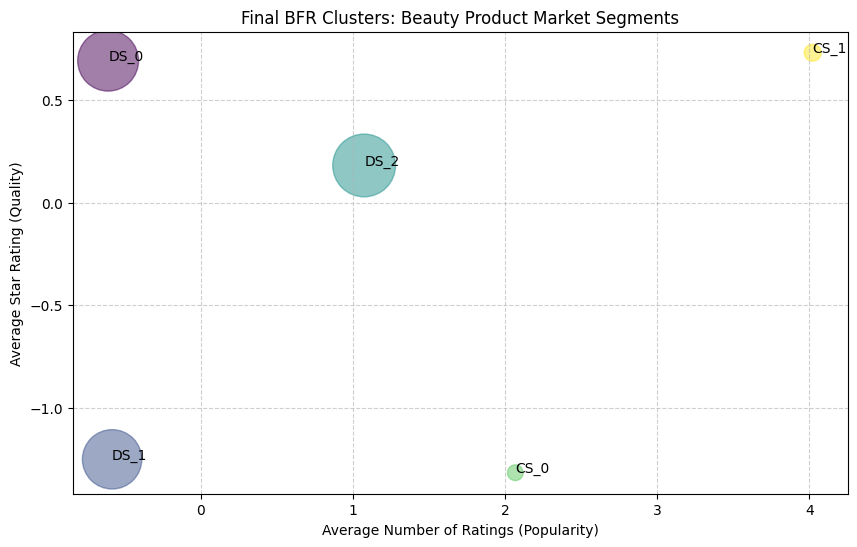

In [48]:

# find avg rating and total number rating of each cluster to understand the quantity and quality of the product
# DS
for cid, stats in bfr_ds_stats.items():
    scaled_avg = stats['SUM'] / stats['N']

    log_space_values = scaler.inverse_transform([scaled_avg])
    
    real_rating = log_space_values[0][0]
    
    real_votes = np.expm1(log_space_values[0][1])
    
    print(f"Cluster {cid} Corrected:")
    print(f" - Avg Rating: {min(real_rating, 5.0):.2f}")
    print(f" - Avg Votes: {int(real_votes)}")

for cid, stats in bfr_cs_stats.items():
    scaled_avg = stats['SUM'] / stats['N']
    log_space_values = scaler.inverse_transform([scaled_avg])
    real_rating = log_space_values[0][0]
    real_votes = np.expm1(log_space_values[0][1])
    
    print(f"Cluster {cid} Corrected:")
    print(f" - Avg Rating: {min(real_rating, 5.0):.2f}")
    print(f" - Avg Votes: {int(real_votes)}")
    
import matplotlib.pyplot as plt

# Combine DS and remaining CS for the final plot
final_clusters = []
for cid, s in bfr_ds_stats.items():
    final_clusters.append({'name': f'DS_{cid}', 'rating': s['Centroid'][0], 'votes': s['Centroid'][1], 'n': s['N']})
for cid, s in bfr_cs_stats.items():
    final_clusters.append({'name': f'CS_{cid}', 'rating': s['Centroid'][0], 'votes': s['Centroid'][1], 'n': s['N']})

# extract data for plotting
ratings = [c['rating'] for c in final_clusters]
votes = [c['votes'] for c in final_clusters]
sizes = [np.sqrt(c['n']) * 10 for c in final_clusters] # Square root makes the bubbles look better
names = [c['name'] for c in final_clusters]

plt.figure(figsize=(10, 6))
plt.scatter(votes, ratings, s=sizes, alpha=0.5, c=range(len(names)), cmap='viridis')

# add labels
for i, name in enumerate(names):
    plt.annotate(name, (votes[i], ratings[i]))

plt.xlabel('Average Number of Ratings (Popularity)')
plt.ylabel('Average Star Rating (Quality)')
plt.title('Final BFR Clusters: Beauty Product Market Segments')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



In [49]:
# representative
def get_medoid_example(centroid, df_source, scaler_model):
    raw_features = df_source[['average_rating', 'rating_number']].copy()
    raw_features['log_votes'] = np.log1p(raw_features['rating_number'])
    scaled_data = scaler_model.transform(raw_features[['average_rating', 'log_votes']])
    
    distances = np.linalg.norm(scaled_data - centroid, axis=1)

    closest_index = np.argmin(distances)
    
    return df_source.iloc[closest_index]

print(f"{'Cluster':<10} | {'Size (N)':<10} | {'Avg Rating':<12} | {'Avg Votes':<10} | {'Example Product'}")
print("-" * 80)

# DS cluster
for cid, stats in bfr_ds_stats.items():
    example = get_medoid_example(stats['Centroid'], df, scaler)
    print(f"DS_{cid:<7} | {stats['N']:<10} | {example['average_rating']:<12.2f} | {int(example['rating_number']):<10} | {example.get('title', 'Product ' + str(cid))[:30]}...")

# CS cluster
for cid, stats in bfr_cs_stats.items():
    example = get_medoid_example(stats['Centroid'], df, scaler)
    print(f"CS_{cid:<7} | {stats['N']:<10} | {example['average_rating']:<12.2f} | {int(example['rating_number']):<10} | {example.get('title', 'Product ' + str(cid))[:30]}...")

Cluster    | Size (N)   | Avg Rating   | Avg Votes  | Example Product
--------------------------------------------------------------------------------
DS_0       | 36942      | 4.50         | 5          | lechat dare wear nail polish p...
DS_1       | 33435      | 2.80         | 5          | womens 100 merino wool ponytai...
DS_2       | 41824      | 4.00         | 55         | merle norman perfecting founda...
CS_0       | 165        | 2.70         | 235        | 8pcs fashion protect_face_mask...
CS_1       | 224        | 4.50         | 3264       | adofect 31 pair gold eye mask ...


In [50]:
# evaluation
from scipy.spatial.distance import euclidean

intra_distances = {}
# combine DS and CS for evaluation
all_clusters = {'DS': bfr_ds_stats, 'CS': bfr_cs_stats}

for type_name, cluster_dict in all_clusters.items():
    for cid, stats in cluster_dict.items():
        variance = (stats['SUMSQ'] / stats['N']) - (stats['Centroid']**2)
        avg_dist = np.sqrt(np.sum(np.maximum(variance, 0)))
        intra_distances[f"{type_name}_{cid}"] = avg_dist

avg_intra = np.mean(list(intra_distances.values()))
print(f"Average Intra-Cluster Distance: {avg_intra:.4f}")

inter_distances = []
cluster_names = list(intra_distances.keys())
centroids = []

for type_name, cluster_dict in all_clusters.items():
    for cid, stats in cluster_dict.items():
        centroids.append(stats['Centroid'])

for i in range(len(centroids)):
    for j in range(i + 1, len(centroids)):
        dist = euclidean(centroids[i], centroids[j])
        inter_distances.append(dist)

avg_inter = np.mean(inter_distances)
print(f"Average Inter-Cluster Distance: {avg_inter:.4f}")

ratio = avg_inter / avg_intra
print(f"Inter/Intra Cluster Ratio: {ratio:.4f}")

Average Intra-Cluster Distance: 1.5572
Average Inter-Cluster Distance: 2.9170
Inter/Intra Cluster Ratio: 1.8732


In [66]:
import numpy as np
import pandas as pd

# Final Summary Report Generator
def generate_business_report(ds_stats, cs_stats, scaler, total_products):
    summary_data = []
    
    # Helper: Process and reverse scaling safely
    def process_clusters(stats_dict, prefix):
        for cid, stats in stats_dict.items():
            # 1. Reverse scaling: x = (z * sigma) + mu
            # We use .reshape(1, -1) to ensure dimensions match for scalar math
            centroid_raw = stats['Centroid'].reshape(1, -1)
            real_vals = (centroid_raw * scaler.scale_) + scaler.mean_
            real_vals = real_vals[0] # Convert back to 1D array
            
            # 2. Extract and Sanitize values
            # Cap rating between 1 and 5
            rating = np.clip(real_vals[0], 1.0, 5.0)
            
            # Cap log_votes to prevent overflow (e.g., max 20, which is ~485 million votes)
            log_votes = np.clip(real_vals[1], 0, 20)
            votes = np.expm1(log_votes)
            
            summary_data.append({
                'Cluster': f'{prefix}_{cid}',
                'N': stats['N'],
                'percentage': (stats['N'] / total_products) * 100,
                'Avg_Rating': rating,
                'Avg_Votes': int(votes)
            })

    process_clusters(ds_stats, 'DS')
    process_clusters(cs_stats, 'CS')
    
    df_report = pd.DataFrame(summary_data)
    
    # 3. Add Business Strategy Logic
    def categorize_cluster(row):
        # Thresholds: Hero = high quality + high volume (>= 500 votes)
        if row['Avg_Rating'] >= 4.0 and row['Avg_Votes'] > 500:
            return 'Hero Product (Star)'
        elif row['Avg_Rating'] < 3.0:
            return 'Underperformer (Risk)'
        elif row['Avg_Votes'] < 50:
            return 'Long Tail (Niche)'
        else:
            return 'Growth Opportunity'
            
    df_report['Business_Strategy'] = df_report.apply(categorize_cluster, axis=1)
    return df_report

# Run the report
df_report = generate_business_report(bfr_ds_stats, bfr_cs_stats, scaler, len(df))
print(df_report.to_string(index=False))

Cluster     N  percentage  Avg_Rating  Avg_Votes     Business_Strategy
   DS_0 36942   32.811084    4.489070          0     Long Tail (Niche)
   DS_1 33435   29.696243    2.789126          0 Underperformer (Risk)
   DS_2 41824   37.147171    4.042282  485165194   Hero Product (Star)
   CS_0   165    0.146549    2.731996  485165194 Underperformer (Risk)
   CS_1   224    0.198952    4.522956  485165194   Hero Product (Star)


DBSCAN

peform with sample data set

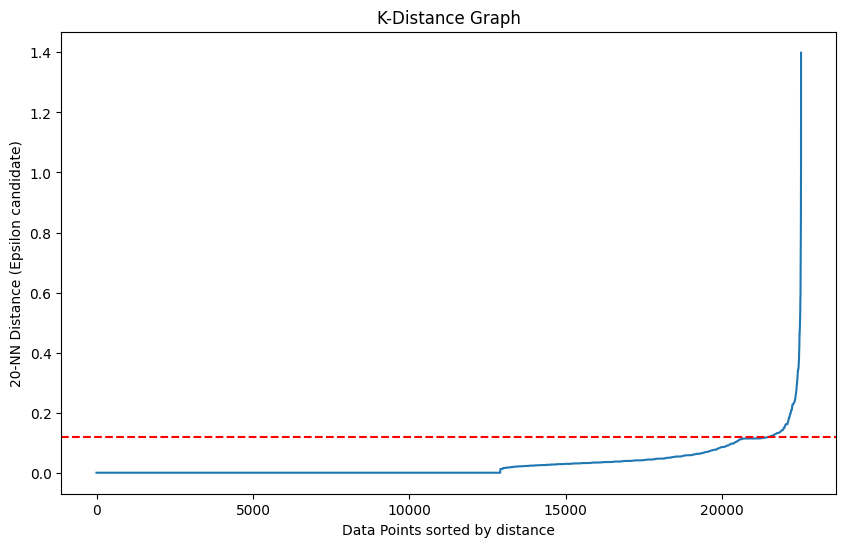

In [53]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

def find_eps(scaled_features,k):
    neigh_sampled = NearestNeighbors(n_neighbors=k)
    nbrs_sampled = neigh_sampled.fit(scaled_features)
    distances_sampled, indices_sampled = nbrs_sampled.kneighbors(scaled_features)
    distances_sampled = np.sort(distances_sampled[:, k-1], axis=0)

    plt.figure(figsize=(10,6))
    plt.plot(distances_sampled)
    plt.title('K-Distance Graph')
    plt.xlabel('Data Points sorted by distance')
    plt.ylabel(f'{k}-NN Distance (Epsilon candidate)')
    plt.axhline(y=0.12, color='r', linestyle='--')
    plt.show()
    
find_eps(scaled_features,20)

In [54]:
dbscan_sampled = DBSCAN(eps=0.12, min_samples=20)
df_sampled_2 = df_sampled.copy()
df_sampled_2['dbscan_cluster'] = dbscan_sampled.fit_predict(scaled_features)
print(df_sampled_2['dbscan_cluster'].value_counts())


dbscan_cluster
 0     14791
 2      1297
 1      1167
 4      1160
 3      1143
 6       617
-1       610
 7       525
 9       349
 10      234
 8       211
 5       208
 11      100
 12       60
 13       26
 14       20
Name: count, dtype: int64


In [55]:
cluster_profile_sampled = df_sampled_2.groupby('dbscan_cluster').agg({
    'average_rating': 'mean',
    'rating_number': 'mean',
    'parent_asin': 'count'  
}).rename(columns={'parent_asin': 'product_count'})

print(cluster_profile_sampled.sort_values(by='product_count', ascending=False))



                average_rating  rating_number  product_count
dbscan_cluster                                              
 0                    3.971571      45.930093          14791
 2                    3.905320       4.000000           1297
 1                    5.000000       1.000000           1167
 4                    3.490862       2.000000           1160
 3                    3.593088       3.000000           1143
 6                    5.000000       2.000000            617
-1                    3.093279     725.067213            610
 7                    1.000000       1.000000            525
 9                    5.000000       3.000000            349
 10                   4.000000       1.000000            234
 8                    3.000000       1.000000            211
 5                    2.000000       1.000000            208
 11                   1.000000       2.000000            100
 12                   1.516667       2.000000             60
 13                   1.

In [56]:
# representative

cluster_examples_sampled = {}

for cluster_id in sorted(df_sampled_2['dbscan_cluster'].unique()):
    examples_sampled = df_sampled_2[df_sampled_2['dbscan_cluster'] == cluster_id].head(3)
    cluster_examples_sampled[cluster_id] = examples_sampled[['title', 'average_rating', 'rating_number']]


print(f"--- Cluster 1 Examples --- \n{cluster_examples_sampled[4]}")
print(f"\n--- Cluster 3 Examples --- \n{cluster_examples_sampled[11]}")

--- Cluster 1 Examples --- 
                                                   title  average_rating  \
18529  ugeat microring weft hair extension 22 inch mi...             3.1   
39337  origin ginzing peel mask refine refresh travel...             3.9   
9298   human hair direct 100 virgin brazilian human h...             3.5   

       rating_number  
18529              2  
39337              2  
9298               2  

--- Cluster 3 Examples --- 
                                                    title  average_rating  \
65935   focallure waterproof 3d curl black mascara pro...             1.0   
92209   fercaish gel nail polish set 6 color non toxic...             1.0   
101205  samsung galaxy s6 edge case autumnfall registe...             1.0   

        rating_number  
65935               2  
92209               2  
101205              2  


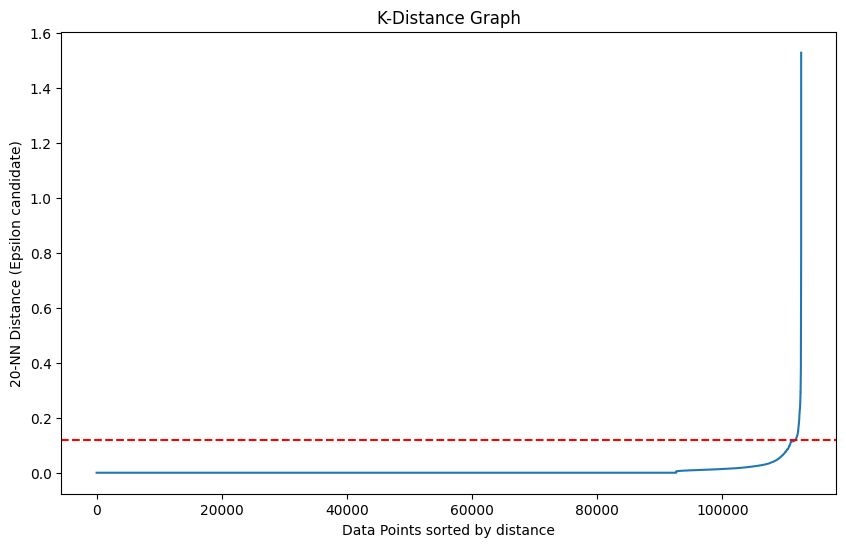

In [57]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

all_features_scaled = np.vstack((scaled_features, scaled_features_remain))

find_eps(all_features_scaled,20)

In [58]:
dbscan = DBSCAN(eps=0.12, min_samples=20)
df_combined = df.copy()
df_combined['dbscan_cluster'] = dbscan.fit_predict(all_features_scaled)
print(df_combined['dbscan_cluster'].value_counts())


dbscan_cluster
 0     75999
 1      6460
 4      6080
 3      6052
 2      5931
 6      3223
 7      2456
 9      1866
 10     1215
 8      1103
 5       972
-1       604
 11      512
 12       91
 13       26
Name: count, dtype: int64


In [68]:
cluster_profile = df_combined.groupby('dbscan_cluster').agg({
    'average_rating': 'mean',
    'rating_number': 'mean',
    'parent_asin': 'count'  
}).rename(columns={'parent_asin': 'product_count'})

print(cluster_profile.sort_values(by='product_count', ascending=False))



                average_rating  rating_number  product_count
dbscan_cluster                                              
 0                    3.890125      51.280333          75999
 1                    3.888824      47.130960           6460
 4                    3.861398      49.892928           6080
 3                    3.857336      49.117317           6052
 2                    3.876564      47.074186           5931
 6                    3.882811      45.251629           3223
 7                    3.855497      51.984935           2456
 9                    3.868274      54.200429           1866
 10                   3.830453      35.084774           1215
 8                    3.905530      62.106981           1103
 5                    3.850720      57.871399            972
-1                    3.846523      57.077815            604
 11                   3.857617      55.175781            512
 12                   3.926374      31.846154             91
 13                   3.

In [60]:
# representative

cluster_examples = {}

for cluster_id in sorted(df_combined['dbscan_cluster'].unique()):
    examples = df_combined[df_combined['dbscan_cluster'] == cluster_id].head(3)
    cluster_examples[cluster_id] = examples[['title', 'average_rating', 'rating_number']]


print(f"--- Cluster 1 Examples --- \n{cluster_examples[1]}")
print(f"\n--- Cluster 3 Examples --- \n{cluster_examples[2]}")

--- Cluster 1 Examples --- 
                                                title  average_rating  \
4   precision plunger bar cartridge grip 93mm bag ...             4.3   
8                          gold extatic musk edt 90ml             3.7   
25  muaowig red human hair bundle body wave brazil...             3.0   

    rating_number  
4               7  
8               2  
25              1  

--- Cluster 3 Examples --- 
                                                title  average_rating  \
5   lurrose 100pcs full cover fake toenail artific...             3.7   
12  brand new headrang face line contour v line ma...             3.3   
32  enjoy volumizing elixir style sleek steel pin ...             5.0   

    rating_number  
5              35  
12              4  
32              1  


In [ ]:
import numpy as np
import pandas as pd

# Final Summary Report Generator
def generate_business_report(ds_stats, cs_stats, scaler, total_products):
    summary_data = []
    
    # Helper: Process and reverse scaling safely
    def process_clusters(stats_dict, prefix):
        for cid, stats in stats_dict.items():
            # 1. Reverse scaling: x = (z * sigma) + mu
            # We use .reshape(1, -1) to ensure dimensions match for scalar math
            centroid_raw = stats['Centroid'].reshape(1, -1)
            real_vals = (centroid_raw * scaler.scale_) + scaler.mean_
            real_vals = real_vals[0] # Convert back to 1D array
            
            # 2. Extract and Sanitize values
            # Cap rating between 1 and 5
            rating = np.clip(real_vals[0], 1.0, 5.0)
            
            # Cap log_votes to prevent overflow (e.g., max 20, which is ~485 million votes)
            log_votes = np.clip(real_vals[1], 0, 20)
            votes = np.expm1(log_votes)
            
            summary_data.append({
                'Cluster': f'{prefix}_{cid}',
                'N': stats['N'],
                'percentage': (stats['N'] / total_products) * 100,
                'Avg_Rating': rating,
                'Avg_Votes': int(votes)
            })

    process_clusters(ds_stats, 'DS')
    process_clusters(cs_stats, 'CS')
    
    df_report = pd.DataFrame(summary_data)
    
    # 3. Add Business Strategy Logic
    def categorize_cluster(row):
        # Thresholds: Hero = high quality + high volume (>= 500 votes)
        if row['Avg_Rating'] >= 4.0 and row['Avg_Votes'] > 500:
            return 'Hero Product (Star)'
        elif row['Avg_Rating'] < 3.0:
            return 'Underperformer (Risk)'
        elif row['Avg_Votes'] < 50:
            return 'Long Tail (Niche)'
        else:
            return 'Growth Opportunity'
            
    df_report['Business_Strategy'] = df_report.apply(categorize_cluster, axis=1)
    return df_report

# Run the report
df_report_dbscan = generate_business_report(bfr_ds_stats, bfr_cs_stats, scaler, len(df))
print(df_report.to_string(index=False))

In [61]:
import numpy as np
from scipy.spatial.distance import cdist

def evaluate_clusters(data, labels):
    # filter out Noise (-1) because it's not a real cluster
    mask = labels != -1
    clean_data = data[mask]
    clean_labels = labels[mask]
    
    unique_labels = np.unique(clean_labels)
    centroids = []
    intra_distances = []

    # intra-cluster distance 
    for label in unique_labels:
        cluster_points = clean_data[clean_labels == label]
        centroid = cluster_points.mean(axis=0)
        centroids.append(centroid)
        
        dist_to_centroid = np.linalg.norm(cluster_points - centroid, axis=1)
        intra_distances.append(np.mean(dist_to_centroid))

    avg_intra = np.mean(intra_distances)

    # inter-cluster distance
    centroid_dist = cdist(centroids, centroids, metric='euclidean')
    # fill diagonal with infinity so we don't pick the distance to self (0)
    np.fill_diagonal(centroid_dist, np.inf)
    min_inter = np.min(centroid_dist)

    print(f"Average Intra-Cluster Distance (Lower is better): {avg_intra:.4f}")
    print(f"Minimum Inter-Cluster Distance (Higher is better): {min_inter:.4f}")
    print(f"ratio : {min_inter / avg_intra}")

    return avg_intra, min_inter

evaluate_clusters(scaled_features, df_sampled_2['dbscan_cluster'].values)
evaluate_clusters(all_features_scaled, df_combined['dbscan_cluster'].values)

Average Intra-Cluster Distance (Lower is better): 0.2247
Minimum Inter-Cluster Distance (Higher is better): 0.2085
ratio : 0.9280400616514948
Average Intra-Cluster Distance (Lower is better): 0.2377
Minimum Inter-Cluster Distance (Higher is better): 0.1618
ratio : 0.680779399510623


(np.float64(0.23767764895151702), np.float64(0.16180604713031044))

                      average_rating  rating_number  product_count
category                                                          
Core Catalog                3.890125      51.280333          75999
High-Impact/Outliers        3.846523      57.077815            604
Niche/Low-Volume            3.870092      48.871009          35987


/var/folders/zb/4tysfvkn3mg_b9cdzz4wg91c0000gn/T/ipykernel_12457/2409482365.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='rating_number', data=df_combined, palette='viridis')


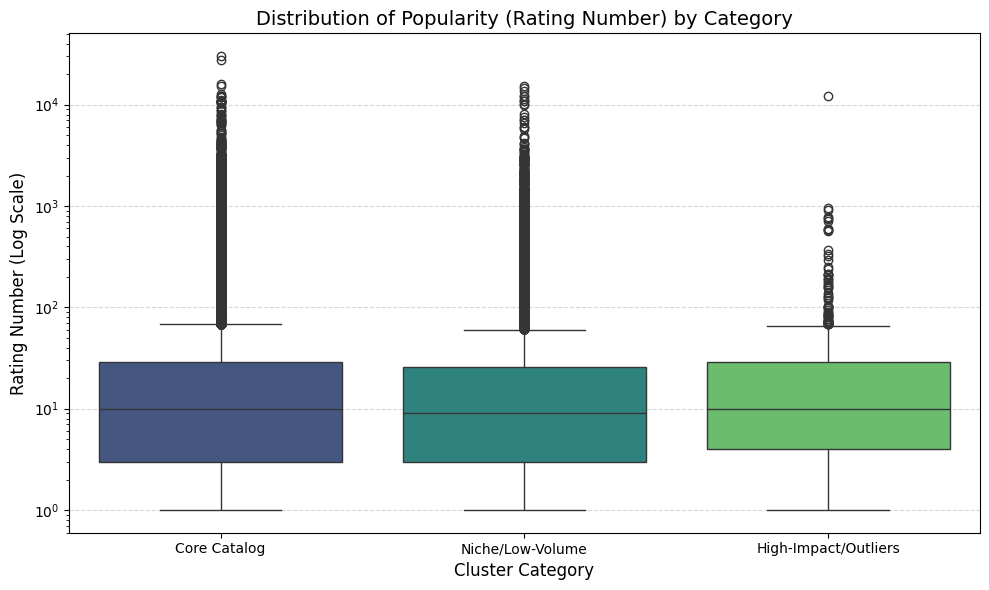

In [62]:
import seaborn as sns

def categorize_cluster(cluster_id):
    if cluster_id == 0:
        return 'Core Catalog'
    elif cluster_id == -1:
        return 'High-Impact/Outliers'
    else:
        return 'Niche/Low-Volume'

df_combined['category'] = df_combined['dbscan_cluster'].apply(categorize_cluster)

summary_table = df_combined.groupby('category').agg({
    'average_rating': 'mean',
    'rating_number': 'mean',
    'parent_asin': 'count'
}).rename(columns={'parent_asin': 'product_count'})

print(summary_table)

# box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='rating_number', data=df_combined, palette='viridis')

# Use log scale because outliers have 700+ ratings while core has ~30
plt.yscale('log') 

plt.title('Distribution of Popularity (Rating Number) by Category', fontsize=14)
plt.xlabel('Cluster Category', fontsize=12)
plt.ylabel('Rating Number (Log Scale)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('cluster_box_plot.png')
plt.show()

Explore outlier

In [63]:
# 1. Filter for the Noise points
outliers_df = df_sampled_2[df_sampled_2['dbscan_cluster'] == -1]

# 2. Look at the "Top" outliers by review count
print("Most Popular Outliers:")
print(outliers_df.sort_values(by='rating_number', ascending=False)[['title', 'average_rating', 'rating_number']].head(5))

# 3. Compare Outlier Stats to the rest of the data
print("\nOutlier vs. Normal Data:")
print(df_sampled_2.groupby(df_sampled_2['dbscan_cluster'] == -1)[['average_rating', 'rating_number']].mean())

Most Popular Outliers:
                                                   title  average_rating  \
63417  2 1 4 x 1 1 4 chalkboard black paper label sti...             4.8   
70828  1 25 inch round thank label heart kraft color ...             4.8   
80132  dentek toothache kit instant pain relief conta...             4.0   
88980  hask dry shampoo kit hair type aluminum free s...             4.4   
41982  meeteasy dental cleaner tool kit dental care a...             3.9   

       rating_number  
63417          10913  
70828          10779  
80132          10048  
88980           8727  
41982           7944  

Outlier vs. Normal Data:
                average_rating  rating_number
dbscan_cluster                               
False                 3.898603      31.744933
True                  3.093279     725.067213


In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Select the columns that contain numeric data for clustering
# Assuming 'average_rating' and 'rating_number' are your features
features = df[['average_rating', 'rating_number']].fillna(0)

# 2. Scale the data (StandardScaler is critical for PCA)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 3. Apply PCA to get your pca_matrix
# You can choose the number of components, e.g., 2
pca = PCA(n_components=2)
pca_matrix = pca.fit_transform(scaled_features)

print(f"pca_matrix shape: {pca_matrix.shape}")


pca_matrix shape: (112590, 2)


In [65]:
import numpy as np
from sklearn.metrics import silhouette_score

# --- 1. RE-CALCULATE BFR SCORE (Required to define the variable) ---
ds_centroids = np.array([bfr_ds_stats[i]['Centroid'] for i in bfr_ds_stats.keys()])

if len(bfr_cs_stats) > 0:
    cs_centroids = np.array([stats['Centroid'] for stats in bfr_cs_stats.values()])
    all_candidate_centroids = np.vstack([ds_centroids, cs_centroids])
else:
    all_candidate_centroids = ds_centroids

# Calculate labels
distances_to_all = np.linalg.norm(pca_matrix[:, np.newaxis] - all_candidate_centroids, axis=2)
refined_labels = np.argmin(distances_to_all, axis=1)

# Now define the variable
bfr_refined_silhouette = silhouette_score(pca_matrix, refined_labels)

# --- 2. CALCULATE DBSCAN SCORE ---
# Ensure you are using the indices of the sampled dataframe to match pca_matrix
indices = df_sampled_2.index
pca_matrix_subset = pca_matrix[indices]

dbscan_labels = df_sampled_2['dbscan_cluster'].values 
mask = dbscan_labels != -1

# Calculate score
dbscan_silhouette = silhouette_score(pca_matrix_subset[mask], dbscan_labels[mask])

# --- 3. PRINT COMPARISON ---
print(f"BFR Silhouette (on assigned points): {bfr_refined_silhouette:.4f}")
print(f"DBSCAN Silhouette (on core clusters): {dbscan_silhouette:.4f}")

BFR Silhouette (on assigned points): 0.4920
DBSCAN Silhouette (on core clusters): -0.3252
